In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.ticker as ticker
from matplotlib import rcParams
import matplotlib.transforms as mtransforms
import numpy as np
from matplotlib.ticker import NullFormatter
import matplotlib.font_manager as fm

def on_press(event):
    print("my position:", event.button, event.xdata, event.ydata)

fontsize = 8
fonttype = 'sans-serif'
mpl.rcParams['font.size'] = fontsize
mpl.rcParams['figure.dpi'] = 150

if (fonttype == 'serif'):
    plt.rcParams['pdf.fonttype'] = 42
    mpl.rc('text', usetex=True)
    mpl.rc('text.latex', preamble=r'\usepackage{amsmath, newtxtext, newtxmath}')
    plt.rcParams['font.family'] = 'serif'
elif (fonttype == 'sans-serif'):
    plt.rcParams['pdf.fonttype'] = 42
    mpl.rc('text', usetex=True)
    plt.rcParams['font.family'] = 'sans-serif'
    latex_preamble = r"""
    \usepackage[T1]{fontenc}
    \usepackage{bm, amsmath, sansmathfonts}    

    \makeatletter
    \AtBeginDocument{
        \DeclareSymbolFont{sansextrabold}{T1}{cmss}{bx}{n}
        \DeclareMathSymbol{+}{\mathbin}{sansextrabold}{"2B}
        \DeclareMathSymbol{=}{\mathrel}{sansextrabold}{"3D}
        \DeclareMathSymbol{<}{\mathrel}{sansextrabold}{"3C}
        \DeclareMathSymbol{>}{\mathrel}{sansextrabold}{"3E}
        \DeclareMathSymbol{|}{\mathord}{sansextrabold}{"7C}
        \DeclareMathSymbol{/}{\mathord}{sansextrabold}{"2F}

        \DeclareSymbolFont{boldsanssymbols}{OMS}{cmsssy}{b}{n}
        \DeclareMathSymbol{-}{\mathbin}{boldsanssymbols}{"00}
        \DeclareMathSymbol{\times}{\mathbin}{boldsanssymbols}{"02}


        \DeclareMathSymbol{\oplus}{\mathbin}{boldsanssymbols}{"08}
        \DeclareMathSymbol{\otimes}{\mathbin}{boldsanssymbols}{"0A}
        \DeclareMathSymbol{\approx}{\mathrel}{boldsanssymbols}{"19}
        \DeclareMathSymbol{\perp}{\mathrel}{boldsanssymbols}{"3F}
        \DeclareMathSymbol{\sim}{\mathrel}{boldsanssymbols}{"18}
        \DeclareMathSymbol{\to}{\mathrel}{boldsanssymbols}{"21}
        \DeclareMathSymbol{\leftarrow}{\mathrel}{boldsanssymbols}{"20}
        \DeclareMathSymbol{\in}{\mathrel}{boldsanssymbols}{"32}

        \let\original@le\le
        \let\original@ge\ge
        \let\original@langle\langle
        \let\original@rangle\rangle

        \renewcommand{\le}{\bm{\original@le}}
        \renewcommand{\ge}{\bm{\original@ge}}
        \renewcommand{\langle}{\bm{\original@langle}}
        \renewcommand{\rangle}{\bm{\original@rangle}}
        \renewcommand{\|}{|\hspace{-1pt}|}
    }
    \makeatother

    \newcommand{\p}{\partial}
    \newcommand{\T}{^{\mathrm{T}}}
    \renewcommand{\vec}[1]{\boldsymbol{#1}}
    \newcommand{\bn}{\vec{\nabla}}
    \newcommand\ii{\mathrm{i}}
    \newcommand\ee{\mathrm{e}}
    \newcommand{\widebar}[1]{\mskip.5\thinmuskip\overline{\mskip-.5\thinmuskip {#1} \mskip-.5\thinmuskip}\mskip.5\thinmuskip}
    \newcommand{\ket}[1]{| #1 \rangle}
    \newcommand{\bra}[1]{\langle #1 |}
    """
    mpl.rc('text.latex', preamble=latex_preamble)

In [7]:
data = np.load("2d-gaussian-wavepacket.npz")
times = data['times'],
psi_ssfm = data['psi_ssfm']
psi_qssfm = data['psi_filtered_qssfm']
psi_density_error = data['density_error']

In [8]:
t = [0, 0.25, 0.5, 0.75, 1.0]
dt = 0.01
show_step = [int(round(i / dt)) for i in t]

rho_SSFM = []
rho_QSSFM = []
rho_error = []
for step in show_step:
    rho_SSFM.append(psi_ssfm[step])
    rho_QSSFM.append(psi_qssfm[step])
    rho_error.append(psi_density_error[step])

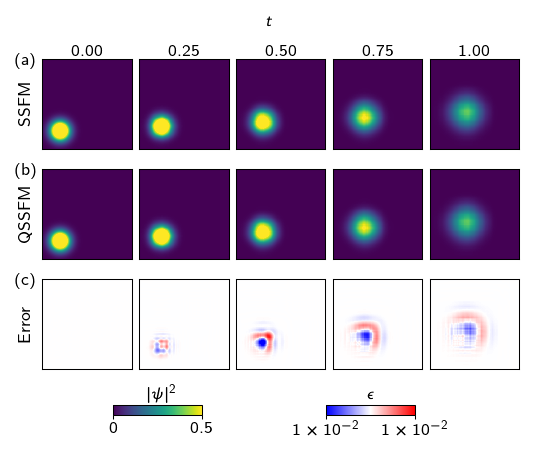

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.ticker import NullFormatter


fontsize = 8
t = [0, 0.25, 0.5, 0.75, 1.0]
dt = 0.01


show_step = [int(round(i / dt)) for i in t]

rho_SSFM = np.array([psi_ssfm[step] for step in show_step])
rho_QSSFM = np.array([psi_qssfm[step] for step in show_step])
rho_error = np.array([psi_density_error[step] for step in show_step])



def style_image_axis(
    ax,
    show_ticks=False,
    xticks=None,
    yticks=None,
    xlabel=None,
    ylabel=None,
    tick_fontsize=8,
    label_fontsize=8
):
    if not show_ticks:
        ax.xaxis.set_major_formatter(NullFormatter())
        ax.yaxis.set_major_formatter(NullFormatter())
    else:
        if xticks is not None:
            ax.set_xticks(xticks)
        if yticks is not None:
            ax.set_yticks(yticks)
        if yticks == []:
            ax.set_yticks([])
        if xlabel is not None:
            ax.set_xlabel(xlabel, fontsize=label_fontsize, labelpad=1)
        if ylabel is not None:
            ax.set_ylabel(ylabel, fontsize=label_fontsize, labelpad=1)

    for spine in ax.spines.values():
        spine.set_linewidth(0.5)

    ax.tick_params(
        axis='x', which='major',
        direction='out', top=False, right=False,
        length=2 if show_ticks else 0,
        width=0.5, pad=1.5,
        labelsize=tick_fontsize
    )
    ax.tick_params(
        axis='y', which='major',
        direction='out', top=False, right=False,
        length=2 if show_ticks else 0,
        width=0.5, pad=1,
        labelsize=tick_fontsize
    )
    ax.tick_params(
        which='minor',
        direction='out', top=False, right=False,
        length=1 if show_ticks else 0,
        width=0.5
    )

fig_width = 8.6 / 2.54
fig_height = 6.8 / 2.54
fig, axes = plt.subplots(3, 5, figsize=(fig_width, fig_height))

ax_width = 1.5/2.54 / fig_width
ax_height = 1.5/2.54 / fig_height

cbar_length = 1.5/2.54 / fig_width
cbar_width = 0.2/2.54 / fig_width


plt.subplots_adjust(
    left=0.04,
    right=0.98,
    bottom=0.18,
    top=0.98,
    wspace=0.08,
    hspace=0.08
)

im_main = None
for i in range(5):
    ax = axes[0, i]
    im_main = ax.imshow(
        rho_SSFM[i],
        origin='lower',
        vmin=0,
        vmax=0.5,
        cmap='viridis'
    )
    style_image_axis(ax)

for i in range(5):
    ax = axes[1, i]
    ax.imshow(
        rho_QSSFM[i],
        origin='lower',
        vmin=0,
        vmax=0.5,
        cmap='viridis'
    )
    style_image_axis(ax)


im_err = None
for i in range(5):
    ax = axes[2, i]
    im_err = ax.imshow(
        rho_error[i],
        origin='lower',
        extent=[-5, 5, -5, 5],
        vmin=-0.01,
        vmax=0.01,
        cmap='bwr'
    )
    style_image_axis(
        ax,
        show_ticks=False,
        xticks=[-5, 5],
        xlabel=r'$x$',
        tick_fontsize=fontsize,
        label_fontsize=fontsize
    )

for i in range(5):
    axes[0, i].set_title(f"${t[i]:.2f}$", fontsize=fontsize, pad=2)

axes[0, 0].text(-0.18, 0.5, "SSFM", transform=axes[0, 0].transAxes,
                rotation=90, va='center', ha='center', fontsize=fontsize)
axes[1, 0].text(-0.18, 0.5, "QSSFM", transform=axes[1, 0].transAxes,
                rotation=90, va='center', ha='center', fontsize=fontsize)
axes[2, 0].text(-0.18, 0.5, "Error", transform=axes[2, 0].transAxes,
                rotation=90, va='center', ha='center', fontsize=fontsize)

row_labels = ['(a)', '(b)', '(c)']
for row in range(3):
    axes[row, 0].text(
        -0.3, 1.08, row_labels[row],
        transform=axes[row, 0].transAxes,
        fontsize=fontsize,
        va='top', ha='left',
        clip_on=False
    )

axes[0, 0].text(2.5, 1.5, r"$t$",transform=axes[0, 0].transAxes, fontsize=fontsize,
    va='top', ha='left',clip_on=False
    )

cax1 = fig.add_axes([0.18, 0.08, cbar_length, cbar_width])
cbar1 = fig.colorbar(im_main, cax=cax1, orientation='horizontal')
cbar1.set_ticks([0, 0.5])
cbar1.set_ticklabels([r'$0$', r'$0.5$'])
cbar1.ax.tick_params(length=2, width=0.5, labelsize=fontsize, pad=1)
cbar1.outline.set_linewidth(0.5)
cbar1.set_label(r'$|\psi|^2$', fontsize=fontsize, labelpad=3)
cbar1.ax.xaxis.set_label_coords(0.55, 1.75)
cbar1.ax.xaxis.set_label_position('top')


cax2 = fig.add_axes([0.60, 0.08, cbar_length, cbar_width])
cbar2 = fig.colorbar(im_err, cax=cax2, orientation='horizontal')
cbar2.set_ticks([-0.01, 0.01])
cbar2.set_ticklabels([r'$1 \times 10^{-2}$', r'$1 \times 10^{-2}$'])
cbar2.ax.tick_params(length=2, width=0.5, labelsize=fontsize, pad=1)
cbar2.outline.set_linewidth(0.5)
cbar2.set_label(r'$\epsilon$', fontsize=fontsize, labelpad=3)
cbar1.ax.xaxis.set_label_coords(0.55, 1.75)
cbar2.ax.xaxis.set_label_position('top')

plt.savefig('2D_gaussian.svg',transparent=True,format='pdf',bbox_inches='tight')
plt.savefig('2D_gaussian.pdf',transparent=True,format='pdf',bbox_inches='tight')

# plt.show()